In [12]:
%pip install numpy pandas matplotlib seaborn tensorflow scikit-learn pillow --quiet

Note: you may need to restart the kernel to use updated packages.


# CIFAKE Model Evaluation & Analysis

Loads the saved best model and evaluates it on the real CIFAKE test set.

Produces:
- Confusion matrix
- Classification report (precision, recall, F1)
- ROC curve + AUC
- Per-class accuracy
- Evaluation report CSV

## 1. Imports & Config

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow: 2.21.0
GPU Available: 0


In [14]:
# Paths
PROJECT_ROOT = Path('../')
DATASET_DIR  = PROJECT_ROOT / 'dataset'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUTPUTS_DIR  = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

IMAGE_SIZE     = 32
BATCH_SIZE     = 64
TARGET_ACCURACY = 0.9298

REAL_DIR = DATASET_DIR / 'REAL'
FAKE_DIR = DATASET_DIR / 'FAKE'

# Model path — training saves as .keras format
MODEL_PATH = MODELS_DIR / 'best_model.keras'
if not MODEL_PATH.exists():
    # Fallback to .hdf5 if someone saved in old format
    MODEL_PATH = MODELS_DIR / 'best_model.hdf5'

print(f"Model path : {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")

Model path : ../models/best_model.keras
Model exists: True


## 2. Load Model

In [15]:
print(f"Loading model from: {MODEL_PATH}")
model = keras.models.load_model(str(MODEL_PATH))
print("✓ Model loaded successfully")
model.summary()

Loading model from: ../models/best_model.keras
✓ Model loaded successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,784 (1006.97 KB)

 Trainable params: 85,682 (334.70 KB)

 Non-trainable params: 736 (2.88 KB)

 Optimizer params: 171,366 (669.40 KB)

## 3. Load & Split Dataset (same splits as training)

In [16]:
def load_images_from_directory(directory, label, image_size=32):
    """Load all images from a directory with a given label."""
    images, labels = [], []
    directory = str(directory)
    if not os.path.exists(directory):
        print(f"WARNING: {directory} not found")
        return np.array([]), np.array([])
    for filename in sorted(os.listdir(directory)):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = keras.preprocessing.image.load_img(
                    os.path.join(directory, filename),
                    target_size=(image_size, image_size)
                )
                images.append(keras.preprocessing.image.img_to_array(img) / 255.0)
                labels.append(label)
            except Exception as e:
                print(f"Skip {filename}: {e}")
    return np.array(images), np.array(labels)

print("Loading REAL images...")
X_real, y_real = load_images_from_directory(REAL_DIR, 0, IMAGE_SIZE)
print(f"  REAL: {X_real.shape}")

print("Loading FAKE images...")
X_fake, y_fake = load_images_from_directory(FAKE_DIR, 1, IMAGE_SIZE)
print(f"  FAKE: {X_fake.shape}")

X = np.concatenate([X_real, X_fake], axis=0)
y = np.concatenate([y_real, y_fake], axis=0)
print(f"\nTotal: {X.shape} | REAL: {(y==0).sum()}, FAKE: {(y==1).sum()}")

Loading REAL images...
  REAL: (50000, 32, 32, 3)
Loading FAKE images...
  FAKE: (50000, 32, 32, 3)

Total: (100000, 32, 32, 3) | REAL: 50000, FAKE: 50000


In [17]:
# Reproduce the SAME 70/15/15 split used in training (same random_state=42)
_, X_temp, _, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

y_test_cat = keras.utils.to_categorical(y_test, 2)

print(f"Test set: {X_test.shape}")
print(f"  REAL: {(y_test==0).sum()} | FAKE: {(y_test==1).sum()}")

Test set: (15000, 32, 32, 3)
  REAL: 7500 | FAKE: 7500


## 4. Run Inference

In [18]:
print("Running predictions on test set...")
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"\n✓ Predictions complete")
print(f"  Predicted REAL: {(y_pred==0).sum()}")
print(f"  Predicted FAKE: {(y_pred==1).sum()}")

Running predictions on test set...
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

✓ Predictions complete
  Predicted REAL: 7593
  Predicted FAKE: 7407


## 5. Performance Metrics

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, batch_size=BATCH_SIZE, verbose=0)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['REAL', 'FAKE'], output_dict=True)

tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # Recall / Sensitivity
fpr = fp / (fp + tn)   # Fall-out
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * precision * tpr / (precision + tpr) if (precision + tpr) > 0 else 0

print("=" * 55)
print("  CIFAKE MODEL — TEST SET EVALUATION")
print("=" * 55)
print(f"  Test Loss          : {test_loss:.4f}")
print(f"  Test Accuracy      : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Target Accuracy    : {TARGET_ACCURACY:.4f}  ({TARGET_ACCURACY*100:.2f}%)")
status = '✓ ACHIEVED' if test_acc >= TARGET_ACCURACY else '✗ BELOW TARGET'
print(f"  Status             : {status}")
print("-" * 55)
print(f"  True Positive Rate : {tpr:.4f}  (Recall — FAKE detected)")
print(f"  False Positive Rate: {fpr:.4f}  (REAL mis-classified as FAKE)")
print(f"  Precision          : {precision:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print("-" * 55)
print(f"  Confusion Matrix:")
print(f"    TN={tn:5d}  FP={fp:5d}")
print(f"    FN={fn:5d}  TP={tp:5d}")
print("=" * 55)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['REAL', 'FAKE']))

  CIFAKE MODEL — TEST SET EVALUATION
  Test Loss          : 0.0656
  Test Accuracy      : 0.9762  (97.62%)
  Target Accuracy    : 0.9298  (92.98%)
  Status             : ✓ ACHIEVED
-------------------------------------------------------
  True Positive Rate : 0.9700  (Recall — FAKE detected)
  False Positive Rate: 0.0176  (REAL mis-classified as FAKE)
  Precision          : 0.9822
  F1 Score           : 0.9761
-------------------------------------------------------
  Confusion Matrix:
    TN= 7368  FP=  132
    FN=  225  TP= 7275

Full Classification Report:
              precision    recall  f1-score   support

        REAL       0.97      0.98      0.98      7500
        FAKE       0.98      0.97      0.98      7500

    accuracy                           0.98     15000
   macro avg       0.98      0.98      0.98     15000
weighted avg       0.98      0.98      0.98     15000



## 6. Plots

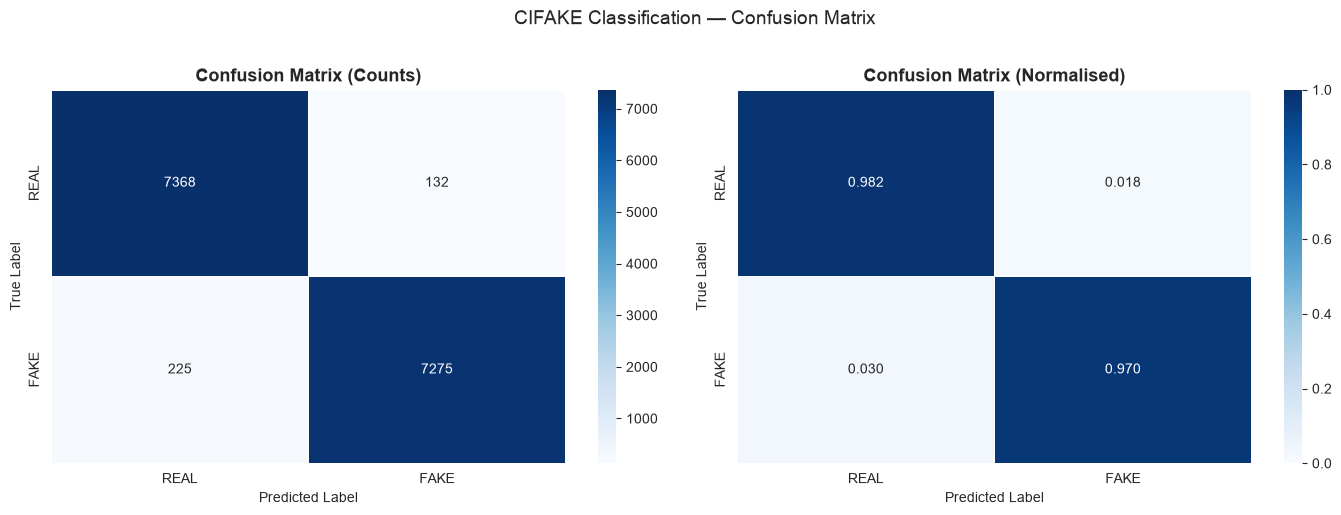

✓ confusion_matrix.png saved


In [20]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'],
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('CIFAKE Classification — Confusion Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ confusion_matrix.png saved")

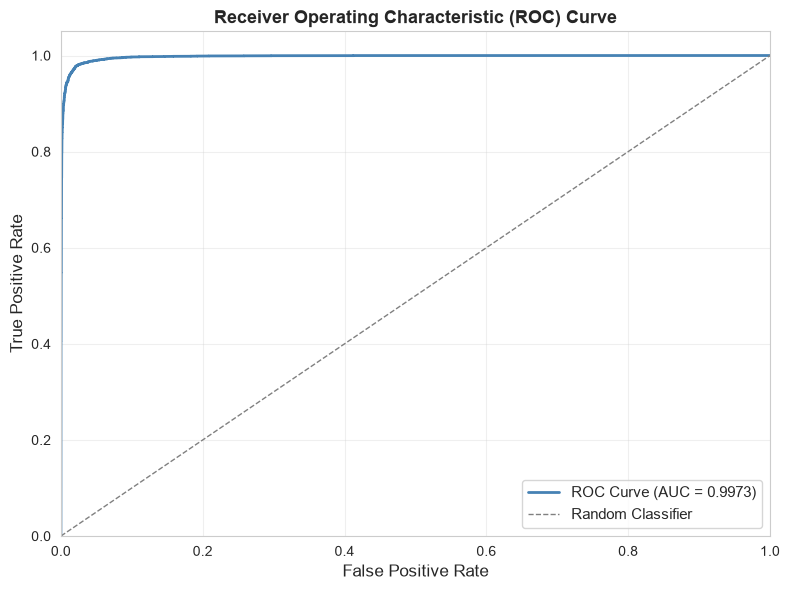

✓ roc_curve.png saved  |  AUC = 0.9973


In [21]:
# --- ROC Curve ---
# Use probability of FAKE (class 1) as the score
fpr_curve, tpr_curve, thresholds = roc_curve(y_test, y_pred_probs[:, 1])
roc_auc = auc(fpr_curve, tpr_curve)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_curve, tpr_curve, color='steelblue', lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ roc_curve.png saved  |  AUC = {roc_auc:.4f}")

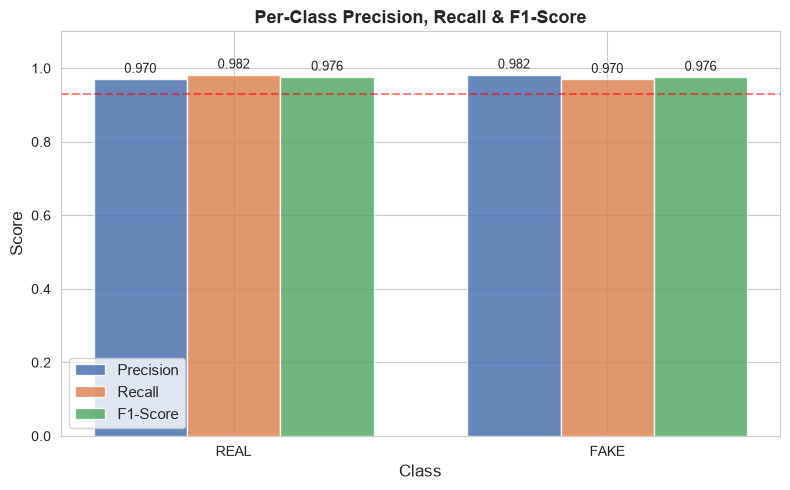

✓ per_class_metrics.png saved


In [22]:
# --- Per-class Metrics Bar Chart ---
classes = ['REAL', 'FAKE']
metrics_names = ['Precision', 'Recall', 'F1-Score']
# sklearn report uses keys: 'precision', 'recall', 'f1-score'
key_map = {'Precision': 'precision', 'Recall': 'recall', 'F1-Score': 'f1-score'}
metrics_data = {
    m: [report[c][key_map[m]] for c in classes]
    for m in metrics_names
}

x = np.arange(len(classes))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metric, values) in enumerate(metrics_data.items()):
    bars = ax.bar(x + i * width, values, width, label=metric, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Class Precision, Recall & F1-Score', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.axhline(y=TARGET_ACCURACY, color='red', linestyle='--', alpha=0.5, label=f'Target ({TARGET_ACCURACY})')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ per_class_metrics.png saved")

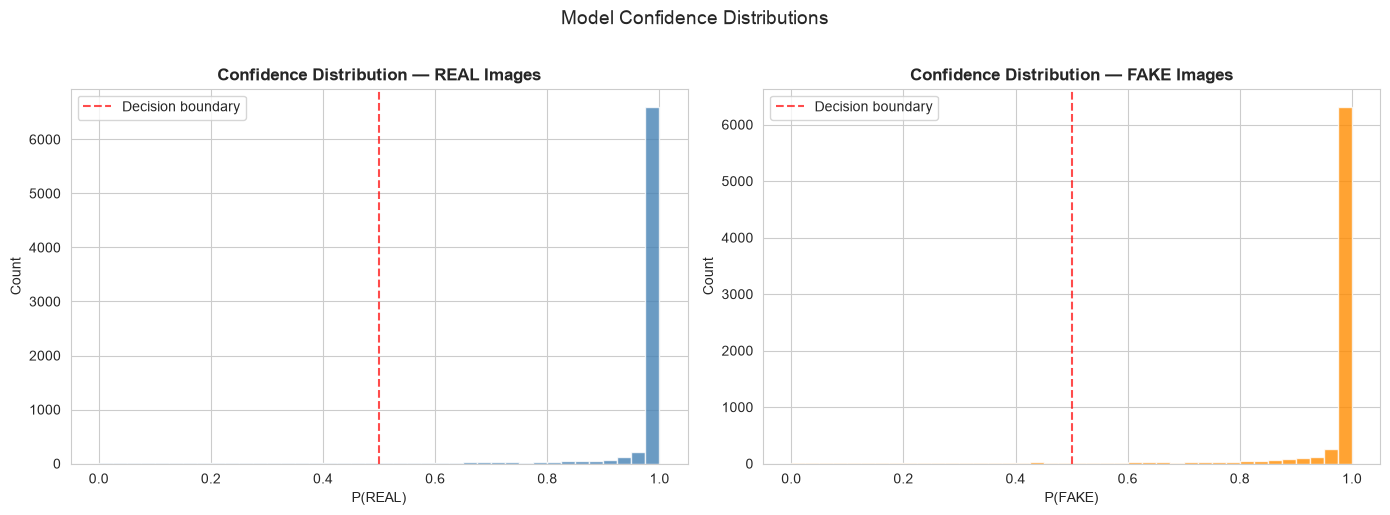

✓ confidence_distributions.png saved


In [23]:
# --- Prediction Confidence Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# REAL samples
real_confs = y_pred_probs[y_test == 0, 0]   # P(REAL) for actual REAL
fake_confs = y_pred_probs[y_test == 1, 1]   # P(FAKE) for actual FAKE

axes[0].hist(real_confs, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Confidence Distribution — REAL Images', fontsize=12, fontweight='bold')
axes[0].set_xlabel('P(REAL)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Decision boundary')
axes[0].legend()

axes[1].hist(fake_confs, bins=40, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('Confidence Distribution — FAKE Images', fontsize=12, fontweight='bold')
axes[1].set_xlabel('P(FAKE)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Decision boundary')
axes[1].legend()

plt.suptitle('Model Confidence Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confidence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ confidence_distributions.png saved")

## 7. Save Evaluation Report

In [24]:
# Save full classification report to CSV
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUTPUTS_DIR / 'evaluation_report.csv')

# Save summary metrics to JSON
import json
summary = {
    'test_loss': float(test_loss),
    'test_accuracy': float(test_acc),
    'target_accuracy': TARGET_ACCURACY,
    'target_achieved': bool(test_acc >= TARGET_ACCURACY),
    'auc_roc': float(roc_auc),
    'true_positive_rate': float(tpr),
    'false_positive_rate': float(fpr),
    'precision': float(precision),
    'f1_score': float(f1),
    'confusion_matrix': {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)},
    'test_samples': int(len(y_test)),
    'model_path': str(MODEL_PATH)
}
with open(OUTPUTS_DIR / 'evaluation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✓ evaluation_report.csv saved")
print(f"✓ evaluation_summary.json saved")
print(f"\n📁 All outputs in: {OUTPUTS_DIR}")

✓ evaluation_report.csv saved
✓ evaluation_summary.json saved

📁 All outputs in: ../outputs


## 8. Summary

In [25]:
print("""
✓ Evaluation Complete!

📊 Results:
""")
print(f"  Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  AUC-ROC        : {roc_auc:.4f}")
print(f"  F1 Score       : {f1:.4f}")
print(f"  TPR (Recall)   : {tpr:.4f}")
print(f"  FPR            : {fpr:.4f}")
print(f"  Target Met     : {'YES ✓' if test_acc >= TARGET_ACCURACY else 'NO ✗'}")
print("""
📁 Saved:
  - outputs/confusion_matrix.png
  - outputs/roc_curve.png
  - outputs/per_class_metrics.png
  - outputs/confidence_distributions.png
  - outputs/evaluation_report.csv
  - outputs/evaluation_summary.json

🚀 Next: Run 04_gradcam_visualization.ipynb
""")


✓ Evaluation Complete!

📊 Results:

  Test Accuracy  : 0.9762 (97.62%)
  AUC-ROC        : 0.9973
  F1 Score       : 0.9761
  TPR (Recall)   : 0.9700
  FPR            : 0.0176
  Target Met     : YES ✓

📁 Saved:
  - outputs/confusion_matrix.png
  - outputs/roc_curve.png
  - outputs/per_class_metrics.png
  - outputs/confidence_distributions.png
  - outputs/evaluation_report.csv
  - outputs/evaluation_summary.json

🚀 Next: Run 04_gradcam_visualization.ipynb

